# Cross-domain evaluation — best model per dataset (source scaling)

**Original execution record** (originally `Cross-All.ipynb`). This run produced `results/cross_domain/source_best/`. Code and outputs are unchanged apart from English comments; paths refer to the original machine (`/opt/flids`).

Each model's scaler is fit on its *source* dataset's validation split and reused for every target. Best models: DNN (UNSW-NB15), MLP (BoT-IoT), LSTM (ToN-IoT), GRU (CIC-2018); `models/base/best/` in the original repo held byte-identical copies of the files now in `models/`. To re-run, use `python scripts/cross_domain_eval.py --scaling source --source-split val`.

In [19]:
import pandas as pd
import numpy as np
import os
import gc

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model

# Scikit-learn
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Used for the heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

directory = "/opt/flids"
save_dir = "/opt/flids/tf/images/cross/"
# Ensure save directory exists
os.makedirs(save_dir, exist_ok=True)

train_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_val.csv"
]

val_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_val.csv"
]

test_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_test.csv"
]

# These names are the keys of the train/val/test dicts
dataset_names = [
    "NFv2-UNSW-NB15",
    "NFv2-BoT-IoT",
    "NFv2-ToN-IoT",
    "NFv2-CIC-2018"
]

model_path = f"{directory}/tf/models/base/best/DNN_NFv2-UNSW-NB15_model.keras"
feature_to_remove = "attack"
train = {}
val = {}
test = {}

# QuantileTransformer with normal output (same scaler as in training)
scaler = QuantileTransformer(output_distribution='normal')

In [20]:

for i, name in enumerate(dataset_names):
    print(f"Loading dataset for: {name}")
    print("-" * 60)

    # =============== Load training split ===============
    df_train = pd.read_csv(train_paths[i])
    df_train.columns = df_train.columns.str.strip().str.lower()  # strip spaces + lower-case
    df_train.dropna(axis=0, inplace=True)                       # drop rows with missing values

    if "label" not in df_train.columns:
        raise ValueError(f"'label' column not found in {train_paths[i]}. "
                         f"Actual columns: {df_train.columns.tolist()}")

    y_train = df_train.pop("label").values  # pop the label column
    if feature_to_remove in df_train.columns:
        df_train.drop(columns=feature_to_remove, inplace=True)  # drop 'attack' if present
    X_train = df_train.values  # to numpy

    # =============== Load validation split ===============
    df_val = pd.read_csv(val_paths[i])
    df_val.columns = df_val.columns.str.strip().str.lower()
    df_val.dropna(axis=0, inplace=True)

    if "label" not in df_val.columns:
        raise ValueError(f"'label' column not found in {val_paths[i]}. "
                         f"Actual columns: {df_val.columns.tolist()}")

    y_val = df_val.pop("label").values
    if feature_to_remove in df_val.columns:
        df_val.drop(columns=feature_to_remove, inplace=True)
    X_val = df_val.values

    # =============== Load test split ===============
    df_test = pd.read_csv(test_paths[i])
    df_test.columns = df_test.columns.str.strip().str.lower()
    df_test.dropna(axis=0, inplace=True)

    if "label" not in df_test.columns:
        raise ValueError(f"'label' column not found in {test_paths[i]}. "
                         f"Actual columns: {df_test.columns.tolist()}")

    y_test = df_test.pop("label").values
    if feature_to_remove in df_test.columns:
        df_test.drop(columns=feature_to_remove, inplace=True)
    X_test = df_test.values

    # store in the global dicts
    train[name] = (X_train, y_train)
    val[name]   = (X_val, y_val)
    test[name]  = (X_test, y_test)

    # free temporaries
    del df_train, df_val, df_test, X_train, X_val, X_test
    del y_train, y_val, y_test
    gc.collect()

print("\nFinished loading all datasets.\n")

Loading dataset for: NFv2-UNSW-NB15
------------------------------------------------------------
Loading dataset for: NFv2-BoT-IoT
------------------------------------------------------------
Loading dataset for: NFv2-ToN-IoT
------------------------------------------------------------
Loading dataset for: NFv2-CIC-2018
------------------------------------------------------------

Finished loading all datasets.



In [21]:
def evaluate_model(model, X_data, y_true, dataset_name=""):

    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Compute False Positive Rate (FPR)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # Avoid division by zero

    print(f"\tAccuracy:  {acc:.4f}")
    print(f"\tPrecision: {prec:.4f}")
    print(f"\tRecall:    {rec:.4f}")
    print(f"\tF1-score:  {f1:.4f}")
    print(f"\tFalse Positive Rate (FPR): {fpr:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # ---------- Plot confusion matrix ----------
    plt.figure(figsize=(6, 5))  # figure size
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix {dataset_name}', fontsize=14)
    plt.xlabel('Predicted label', fontsize=12)
    plt.ylabel('True label', fontsize=12)
    plt.tight_layout()
    # Save the confusion matrix
    save_path = os.path.join(save_dir, f"Confusion_Matrix_{dataset_name}.png")
    plt.savefig(save_path, dpi=300)


def test_model(model_path, name):
    print(f'Fitting and testing for {name}:')
    print('=' * 80 + '\n')

    # Fetch the splits
    X_train_raw, y_train = train[name]
    X_val_raw,   y_val   = val[name]
    X_test_raw,  y_test  = test[name]

    # Scale features
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled   = scaler.transform(X_val_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    model = tf.keras.models.load_model(model_path)

    print("INTER-DATASET EVALUATION:")
    all_names = list(train.keys())
    all_names.remove(name)  # exclude the source dataset
    for other_name in all_names:
        print(f"Evaluation on {other_name}:")
        X_test_other, y_test_other = test[other_name]
        X_test_other_scaled = scaler.transform(X_test_other)
        evaluate_model(model, X_test_other_scaled, y_test_other,
                       dataset_name=f"{name}_{other_name}")

Fitting and testing for NFv2-UNSW-NB15:

INTER-DATASET EVALUATION:
Evaluation on NFv2-BoT-IoT:
	Accuracy:  0.8435
	Precision: 0.8007
	Recall:    0.9147
	F1-score:  0.8539
	False Positive Rate (FPR): 0.2276
Evaluation on NFv2-ToN-IoT:
	Accuracy:  0.2718
	Precision: 0.1643
	Recall:    0.1117
	F1-score:  0.1330
	False Positive Rate (FPR): 0.5680
Evaluation on NFv2-CIC-2018:
	Accuracy:  0.2648
	Precision: 0.0969
	Recall:    0.0565
	F1-score:  0.0714
	False Positive Rate (FPR): 0.5269


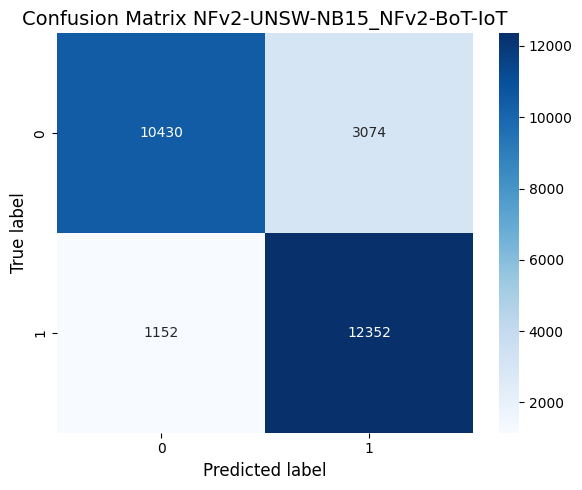

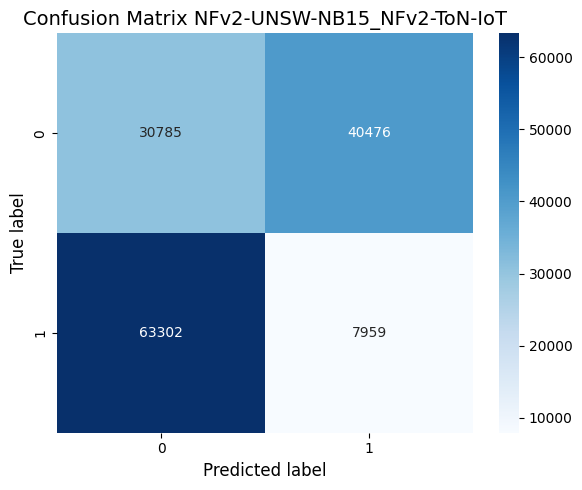

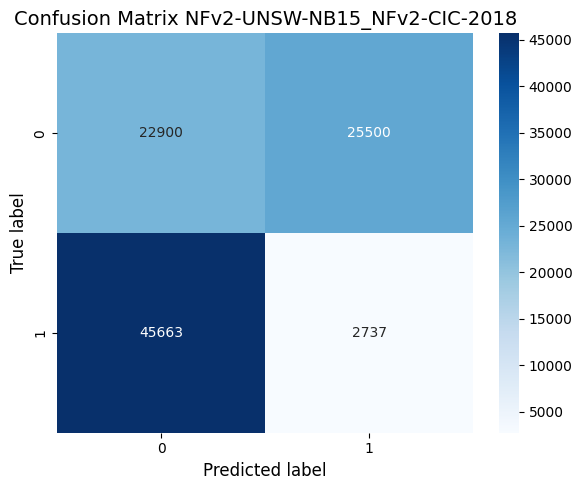

In [22]:
test_model(f"{directory}/tf/models/base/best/DNN_NFv2-UNSW-NB15_model.keras", "NFv2-UNSW-NB15")

Fitting and testing for NFv2-BoT-IoT:

INTER-DATASET EVALUATION:
Evaluation on NFv2-UNSW-NB15:
	Accuracy:  0.4987
	Precision: 0.4167
	Recall:    0.0086
	F1-score:  0.0169
	False Positive Rate (FPR): 0.0121
Evaluation on NFv2-ToN-IoT:
	Accuracy:  0.4753
	Precision: 0.1458
	Recall:    0.0102
	F1-score:  0.0190
	False Positive Rate (FPR): 0.0595
Evaluation on NFv2-CIC-2018:
	Accuracy:  0.5015
	Precision: 0.7110
	Recall:    0.0052
	F1-score:  0.0103
	False Positive Rate (FPR): 0.0021


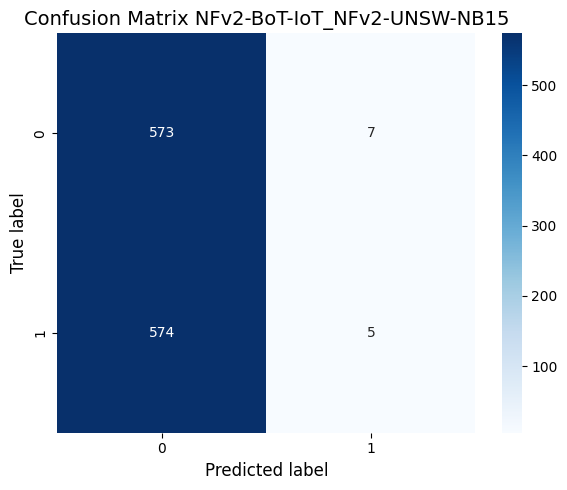

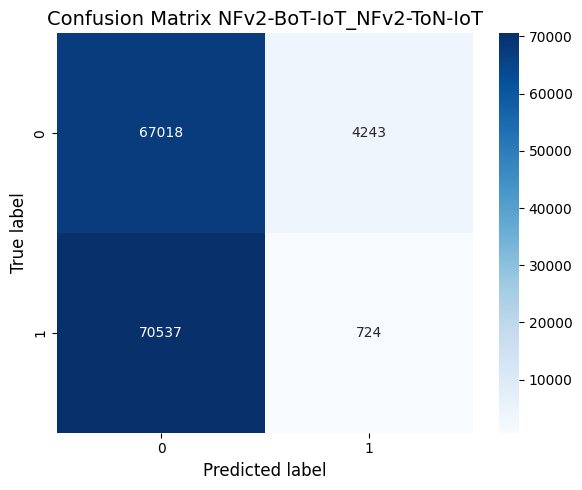

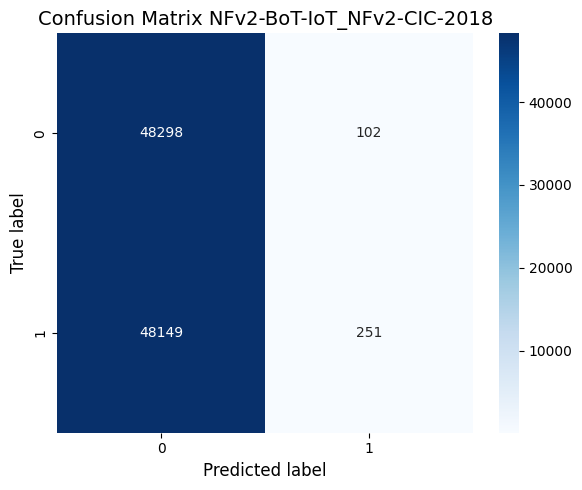

In [23]:
test_model(f"{directory}/tf/models/base/best/MLP_NFv2-BoT-IoT_model.keras", "NFv2-BoT-IoT")

Fitting and testing for NFv2-ToN-IoT:

INTER-DATASET EVALUATION:
Evaluation on NFv2-UNSW-NB15:
	Accuracy:  0.4996
	Precision: 0.0000
	Recall:    0.0000
	F1-score:  0.0000
	False Positive Rate (FPR): 0.0017
Evaluation on NFv2-BoT-IoT:
	Accuracy:  0.4965
	Precision: 0.0000
	Recall:    0.0000
	F1-score:  0.0000
	False Positive Rate (FPR): 0.0070
Evaluation on NFv2-CIC-2018:
	Accuracy:  0.4991
	Precision: 0.4970
	Recall:    0.1494
	F1-score:  0.2298
	False Positive Rate (FPR): 0.1512


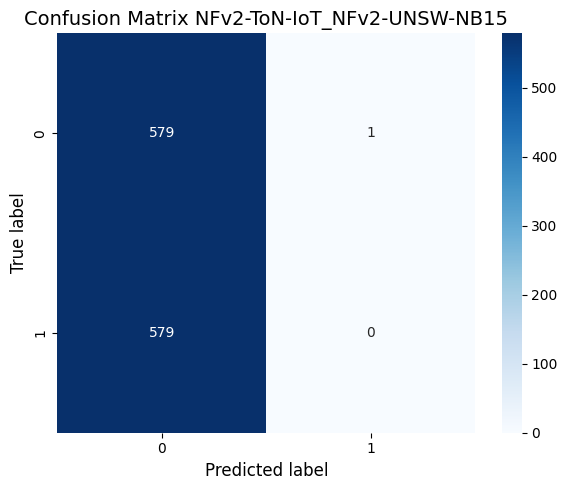

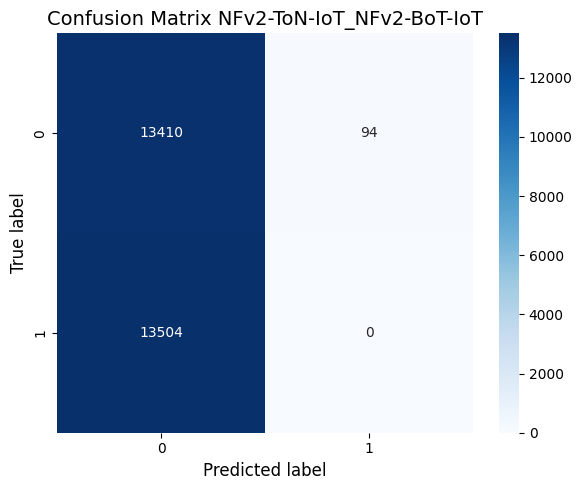

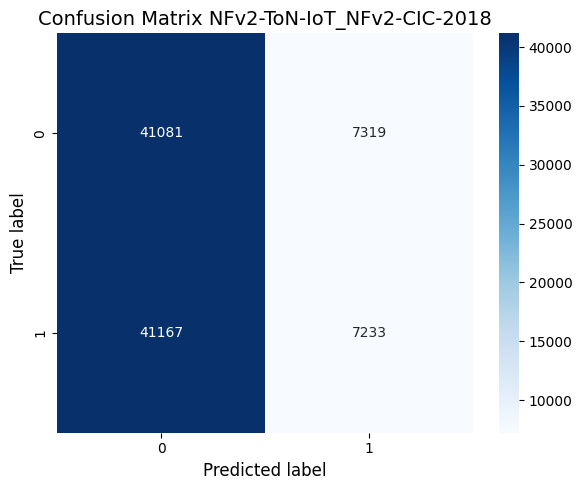

In [24]:
test_model(f"{directory}/tf/models/base/best/LSTM_NFv2-ToN-IoT_model.keras", "NFv2-ToN-IoT")

Fitting and testing for NFv2-CIC-2018:

INTER-DATASET EVALUATION:
Evaluation on NFv2-UNSW-NB15:
	Accuracy:  0.4599
	Precision: 0.0727
	Recall:    0.0069
	F1-score:  0.0126
	False Positive Rate (FPR): 0.0879
Evaluation on NFv2-BoT-IoT:
	Accuracy:  0.8169
	Precision: 0.9987
	Recall:    0.6346
	F1-score:  0.7760
	False Positive Rate (FPR): 0.0008
Evaluation on NFv2-ToN-IoT:
	Accuracy:  0.4515
	Precision: 0.0019
	Recall:    0.0002
	F1-score:  0.0003
	False Positive Rate (FPR): 0.0972


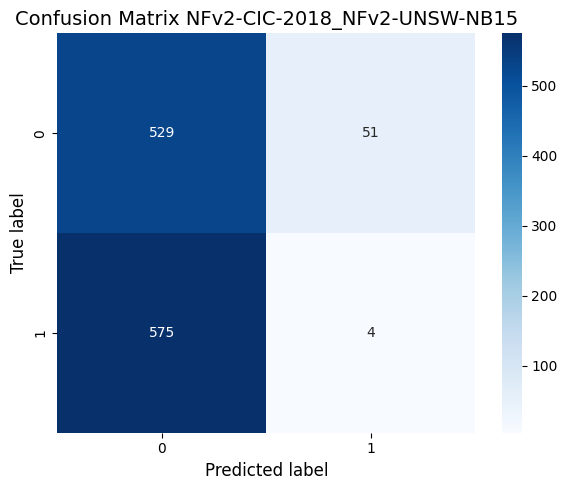

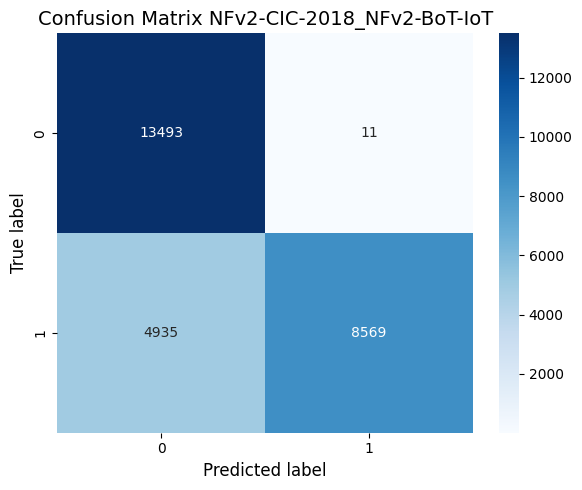

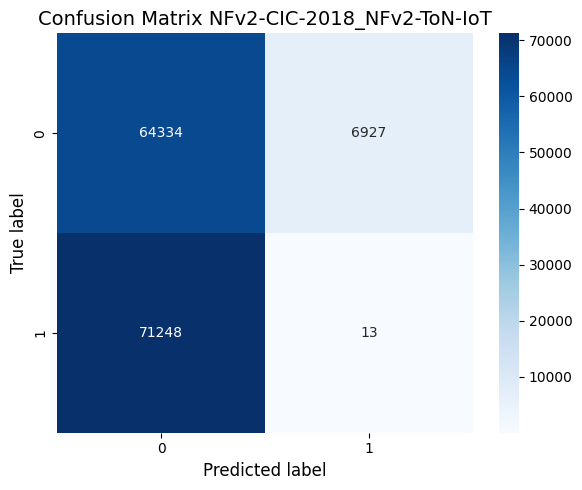

In [27]:
test_model(f"{directory}/tf/models/base/best/GRU_NFv2-CIC-2018_model.keras", "NFv2-CIC-2018")